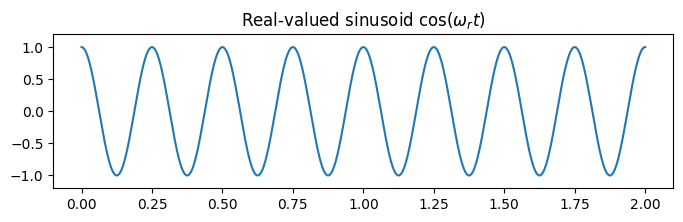

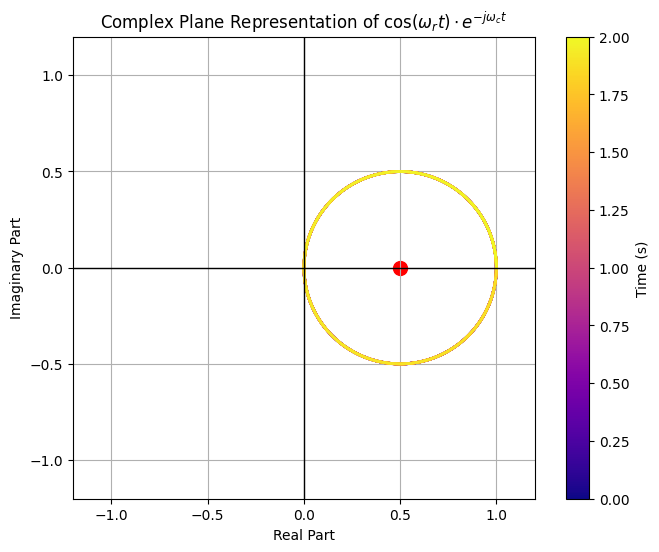

In [21]:
# @title Visualization of Fourier transform

# @markdown Heavily influenced by [this amazing 3Blue1Brown YouTube video](https://www.youtube.com/watch?v=spUNpyF58BY&themeRefresh=1)

real_type = "cosine" # @param ["sine", "cosine"]
freq_real_hz = 4 # @param {type:"number"}
freq_complex_hz = 4 # @param {type:"number"}
num_complex_cycles_to_plot = 8 # @param {type:"number"}
plot_type = "continuous" # @param ["continuous", "discrete"]
num_points = 1024 # @param {type:"integer"}


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the angular frequency and time range
omega_real = 2 * np.pi * freq_real_hz
omega_complex = 2 * np.pi * freq_complex_hz
max_time = num_complex_cycles_to_plot / freq_complex_hz
t = np.linspace(0, max_time, num_points)  # Time range from 0 to 2 seconds

# Compute the complex sinusoid phasor e^(-jwt)
complex_phasor = np.exp(-1 * 1j * omega_complex * t)

# Compute the real-valued function cos(wt)
if real_type == 'sine':
    real_sinusoid = np.sin(omega_real * t)
else:
    real_sinusoid = np.cos(omega_real * t)
# Multiply the complex phasor by the real-valued function
result = real_sinusoid * complex_phasor

# Plot real value
#if freq_real_hz > 0:
plt.figure(figsize=(8, 2))
plt.title(f'Real-valued sinusoid ${"\\sin" if real_type == "sine" else "\\cos"}(\\omega_r t)$')
plt.plot(t, real_sinusoid)
plt.ylim(-1.2, 1.2)
plt.show()

# Plotting in the complex plane
plt.figure(figsize=(8, 6))

# Plot data
if plot_type == 'continuous':
    # Create a set of line segments
    points = np.array([result.real, result.imag]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Create a LineCollection
    lc = mcoll.LineCollection(segments, cmap='plasma', norm=plt.Normalize(0, max_time))
    lc.set_array(t)
    lc.set_linewidth(2)
    plt.gca().add_collection(lc)

    # Add a color bar representing time
    colorbar = plt.colorbar(lc, label='Time (s)')
elif plot_type == 'discrete':
    # Create a scatter plot with a color gradient
    scatter = plt.scatter(result.real, result.imag, c=t, cmap='plasma')

    # Add a color bar representing time
    colorbar = plt.colorbar(scatter)
    colorbar.set_label('Time (s)')
else:
    plt.plot(result.real, result.imag, label='f_r(t) = cos(wt) * e^(-jwt)')

# Customize axes
plt.axhline(0, color='black', linewidth=1)  # Thick horizontal axis
plt.axvline(0, color='black', linewidth=1)  # Thick vertical axis
plt.title(f'Complex Plane Representation of ${"\\sin" if real_type == "sine" else "\\cos"}(\\omega_r t) \\cdot e^{{-j \\omega_c t}}$')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
#plt.axis('equal')  # Ensures equal scaling for both axes
#plt.gca().set_aspect('equal', adjustable='datalim')
#plt.xlim(-1.2, 1.2)
#plt.ylim(-1.2, 1.2)
ax = plt.gca()  # Get current axis
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio and adjust box size
ax.set_xlim(-1.2, 1.2)  # Set x-axis limits
ax.set_ylim(-1.2, 1.2)  # Set y-axis limits
plt.grid(True)
#plt.legend()

# Plot "center of mass"
plt.scatter(
    np.mean(result.real),
    np.mean(result.imag),
    color='red', s=100)

plt.show()